In [143]:
import numpy as np
import pandas as pd
import fastbox as fb
#fb.set_server(0) 
#connection via vpn is strongly recommanded

In [126]:
fb.auth()

Please enter your user name and password for authentication.

Please input your user name:

 egrishin.25@saif.sjtu.edu.cn


Please input your password:

 ········


Fastbox: Configuration saved to fastbox_config.pkl.


User authorized.

## Checking Dataset

We first inspect the stock master table obtained from `fb.data.stocks.info()`.

- Each row corresponds to a **single stock**, indexed by `instrumentid`.
- The dataset contains **firm-level metadata**, including:
  - `exchange` (listing exchange)
  - `industry` (industry classification)
  - `area` (region)
  - `market` (Main Board, ChiNext, etc.)
  - listing and delisting dates

The `instrumentid` is used as the **unique identifier** and serves as the key for merging with daily stock data.


In [330]:
df = fb.data.stocks.info()

In [331]:
df

,exchange,name,area,industry,fullname,enname,cnspell,market,curr_type,list_status,list_date,delist_date,is_hs
instrumentid,,,,,,,,,,,,,
300330,SZSE,计通退(退),None,None,上海华虹计通智能系统股份有限公司,"Shanghai Huahong Jitong Smart System Co.,Ltd.",jtt,创业板,CNY,D,2012-06-19 09:30:00+08:00,2023-05-24 15:30:00+08:00,N
000401,SZSE,金隅冀东,河北,水泥,金隅冀东水泥集团股份有限公司,"Bbmg Jidong Cement Group Co.,Ltd",jyjd,主板,CNY,L,1996-06-14 09:30:00+08:00,NaT,S
000429,SZSE,粤高速A,广东,路桥,广东省高速公路发展股份有限公司,Guangdong Provincial Expressway Development Co...,ygsa,主板,CNY,L,1998-02-20 09:30:00+08:00,NaT,S
000498,SZSE,山东路桥,山东,建筑工程,山东高速路桥集团股份有限公司,"Shandong Hi-Speed Road&Bridge Group Co., Ltd.",sdlq,主板,CNY,L,1997-06-09 09:30:00+08:00,NaT,S
000506,SZSE,招金黄金,山东,黄金,招金国际黄金股份有限公司,"Zhaojin International Gold Co., Ltd.",zjhj,主板,CNY,L,1993-03-12 09:30:00+08:00,NaT,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
600762,SSE,S*ST金荔(退),None,None,衡阳市金荔科技农业股份有限公司,Hunan Hengyang Jinli Technology (Agricultural)...,sstjl,主板,CNY,D,1996-10-25 09:30:00+08:00,2007-11-20 15:30:00+08:00,N
600767,SSE,退运盛(退),None,None,运盛(成都)医疗科技股份有限公司,Winsan(Chengdu) Medical Science and Technology...,tsys,主板,CNY,D,1996-11-15 09:30:00+08:00,2023-06-29 15:30:00+08:00,N
600772,SSE,S*ST龙昌(退),None,None,中油龙昌股份有限公司,"Long Champ Co.,Ltd",sstlc,主板,CNY,D,1996-11-04 09:30:00+08:00,2006-11-30 15:30:00+08:00,N


In [332]:
print(type(df))
print(df.shape)
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
(6033, 13)
Index(['exchange', 'name', 'area', 'industry', 'fullname', 'enname', 'cnspell',
       'market', 'curr_type', 'list_status', 'list_date', 'delist_date',
       'is_hs'],
      dtype='object')


In [333]:
df["industry"].value_counts().head(20)

industry
电气设备    358
元器件     315
软件服务    302
专用机械    299
汽车配件    274
化工原料    271
半导体     191
医疗保健    183
化学制药    156
机械基件    151
通信设备    139
建筑工程    135
环境保护    125
电器仪表    121
食品      100
家用电器     97
塑料       86
生物制药     84
IT设备     83
互联网      80
Name: count, dtype: int64

# QUESTION 1: Linear Classification and Feature Selection
# 1. Linear Classification Comparison:
## Industry Filtering: Food (食品)

Using the stock master table, we filter firms whose `industry` label equals **食品**.

This operation produces a subset (`df_food`) that contains **only Food-industry stocks**, including firm identifiers, exchange information, listing status, and basic metadata.

The resulting `instrumentid` values from this subset are used as the stock universe for downstream daily feature extraction and classification tasks.


In [334]:
df_food = df[df["industry"] == "食品"]
df_food

,exchange,name,area,industry,fullname,enname,cnspell,market,curr_type,list_status,list_date,delist_date,is_hs
instrumentid,,,,,,,,,,,,,
000523,SZSE,红棉股份,广东,食品,广州市红棉智汇科创股份有限公司,Hongmian Zhihui Science and Technology Innovat...,hmgf,主板,CNY,L,1993-11-08 09:30:00+08:00,NaT,S
000529,SZSE,广弘控股,广东,食品,广东广弘控股股份有限公司,"Guangdong Guanghong Holdings Co.,Ltd.",ghkg,主板,CNY,L,1993-11-18 09:30:00+08:00,NaT,N
600737,SSE,中粮糖业,新疆,食品,中粮糖业控股股份有限公司,"Cofco Sugar Holding Co.,Ltd",zlty,主板,CNY,L,1996-07-31 09:30:00+08:00,NaT,H
000716,SZSE,黑芝麻,广西,食品,南方黑芝麻集团股份有限公司,"Nanfang Black Sesame Group Co.,Ltd.",hzm,主板,CNY,L,1997-04-18 09:30:00+08:00,NaT,S
002286,SZSE,保龄宝,山东,食品,保龄宝生物股份有限公司,"Baolingbao Biology Co., Ltd",blb,主板,CNY,L,2009-08-28 09:30:00+08:00,NaT,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
839273,BSE,一致魔芋,湖北,食品,湖北一致魔芋生物科技股份有限公司,"Hubei Yizhi Konjac Biotechnology Co.,Ltd.",yzmy,北交所,CNY,L,2023-02-21 09:30:00+08:00,NaT,N
839371,BSE,欧福蛋业,江苏,食品,苏州欧福蛋业股份有限公司,"Suzhou Ovodan Foods Co.,Ltd.",ofdy,北交所,CNY,L,2023-01-18 09:30:00+08:00,NaT,N
920422,BSE,润普食品,江苏,食品,江苏润普食品科技股份有限公司,Jiangsu Mupro Ift Corp.,rpsp,北交所,CNY,L,2023-03-01 09:30:00+08:00,NaT,N


In [335]:
df["is_food"] = (df["industry"] == "食品").astype(int)
df["is_food"].value_counts()

is_food
0    5933
1     100
Name: count, dtype: int64

In [336]:
food_ids = df_food.index.tolist()
food_ids[:10]

['000523',
 '000529',
 '600737',
 '000716',
 '002286',
 '002820',
 '300829',
 '000972',
 '002695',
 '002840']

In [337]:
df_all = fb.data.stocks.info()

food_ids = df_all[df_all["industry"] == "食品"].index.astype(str).tolist()
len(food_ids)


100

## Daily Stock Data for Food Industry

Using the list of Food-industry instrument IDs, we retrieve **daily stock-level OHLCV data** via  
`fb.data.stocks.daily` for the period **2025-01-01 to 2025-12-25**.

The resulting dataset (`df_index`) has a **MultiIndex** structure:
- level 0: `date`
- level 1: `instrumentid`

Each row corresponds to a single **(date, stock)** observation and includes:
- price variables (`open`, `high`, `low`, `close`)
- trading activity (`vol`, `amount`)
- stock identifiers (`name`, `zhengzhouid`)

This dataset forms the basis for subsequent **feature engineering and classification analysis**.


In [338]:
df_index = fb.data.stocks.daily(
    instrumentid=food_ids,
    complete=True,
    from_date="2025-01-01",
    to_date="2025-12-25"
)

df_index.head()


close      open      high       low         vol  \
date       instrumentid                                                       
2025-01-02 000505        6.031646  6.131343  6.250979  5.981798    90023.60   
           000523        3.050000  3.050000  3.170000  3.020000   269472.60   
           000529        5.784945  5.735920  5.951630  5.716310    87796.97   
           000639        3.690000  3.580000  3.790000  3.550000   501838.67   
           000716        7.512039  6.767781  7.512039  6.618930  1153955.58   

                                amount  name  zhengzhouid  
date       instrumentid                                    
2025-01-02 000505         55283.670035  京粮控股  000505.SZSE  
           000523         83415.726000  红棉股份  000523.SZSE  
           000529         51413.186584  广弘控股  000529.SZSE  
           000639        186110.917000  西王食品  000639.SZSE  
           000716        845323.206426   黑芝麻  000716.SZSE

## Feature Engineering and Sample Construction

Starting from the daily stock data, we construct the following features:

- **Return**: daily percentage return computed as `pct_change(close)` for each stock (`groupby instrumentid`).
- **Log volume**: logarithm of trading volume, used as a liquidity proxy.
- **Intraday volatility**: `(high − low) / open`, capturing daily price dispersion.

Observations with missing values (mainly due to the return calculation) are removed.


In [340]:
df = df_index.copy()

df["return"] = df.groupby("instrumentid")["close"].pct_change()
df["log_volume"] = np.log(df["vol"])
df["intraday_vol"] = (df["high"] - df["low"]) / df["open"]

df = df.dropna()

## Binary Label Definition

A binary classification label is created based on daily returns:

- `label = 1` if the daily return is positive,
- `label = 0` otherwise.

This formulation transforms the problem into a **directional return prediction task**.


In [341]:
df["label"] = (df["return"] > 0).astype(int)

## Random Sampling of Observations

**100 daily snapshots** are randomly sampled from the cleaned dataset.
The resulting sample includes both features and labels and serves as the input for model training and evaluation.
A fixed random seed ensures reproducibility.


In [342]:
df_sample = df.sample(n=100, random_state=42)

X = df_sample[["log_volume", "intraday_vol"]]
y = df_sample["label"]

In [343]:
df_sample

,,close,open,high,low,vol,amount,name,zhengzhouid,return,log_volume,intraday_vol,label
date,instrumentid,,,,,,,,,,,,
2025-06-09,605089,24.360823,24.055328,24.439661,23.858234,10321.96,24912.612757,味知香,605089.SSE,0.011043,9.242029,0.024170,1
2025-04-18,603182,12.449003,12.623794,12.623794,12.274212,43520.00,54147.106508,嘉华股份,603182.SSE,-0.013846,10.680976,0.027692,0
2025-07-29,605077,17.647328,17.617652,17.657220,17.311000,29658.43,51787.593084,华康股份,605077.SSE,0.006204,10.297502,0.019652,1
2025-03-19,300972,82.346965,81.569637,83.971382,81.320493,19234.60,158677.217369,万辰集团,300972.SZSE,0.008913,9.864466,0.032498,1
2025-08-01,300858,20.400000,16.830000,20.400000,16.830000,342458.83,663050.299000,科拓生物,300858.SZSE,0.200000,12.743907,0.212121,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,920826,14.700000,14.500000,14.760000,14.290000,92924.57,134382.259000,盖世食品,920826.BSE,0.001362,11.439543,0.032414,1
2025-09-17,920273,41.270000,42.120000,42.170000,41.030000,18067.91,74635.097000,一致魔芋,920273.BSE,-0.006978,9.801893,0.027066,0
2025-08-26,002557,23.240000,23.300000,23.400000,23.120000,84690.67,197021.162000,洽洽食品,002557.SZSE,-0.003858,11.346761,0.012017,0


## Train–Test Split and Model Setup

The dataset is split into training and test sets using a **70/30 split**:

$\mathcal{D} = \mathcal{D}_{\text{train}} \cup \mathcal{D}_{\text{test}}, 
\; |\mathcal{D}_{\text{train}}| = 0.7N, 
\; |\mathcal{D}_{\text{test}}| = 0.3N$

where $N$ denotes the total number of observations.

Two linear classifiers are trained using sklearn pipelines:

- **Logistic Regression**
- **Linear Support Vector Machine (SVM)**

Both models are embedded in a pipeline with `StandardScaler`, which standardizes each feature $x_j$ as:

$x_j^{(s)} = \frac{x_j - \mu_j}{\sigma_j}$

where $\mu_j$ and $\sigma_j$ are the mean and standard deviation estimated **only from the training set**.

This pipeline-based setup ensures that:
- feature scaling is learned exclusively from $\mathcal{D}_{\text{train}}$,
- the same transformation is consistently applied to $\mathcal{D}_{\text{test}}$,
- data leakage between training and test sets is avoided.


### Logistic Regression

Logistic Regression models the conditional probability of a positive class as:

$P(y=1 \mid x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$

The model parameters $(w, b)$ are estimated by minimizing the **log-loss (negative log-likelihood)**:

$\mathcal{L}_{\text{logit}} = - \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]$

where $\hat{y}_i = P(y=1 \mid x_i)$.

### Linear Support Vector Machine (SVM)

The Linear SVM predicts class labels using the decision function:

$\hat{y} = \text{sign}(w^T x + b)$

Model parameters are obtained by minimizing the **hinge-loss objective with margin regularization**:

$\mathcal{L}_{\text{SVM}} = \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{N} \max\left(0,\, 1 - y_i (w^T x_i + b)\right)$

where $C > 0$ controls the trade-off between margin maximization and classification error.


In [318]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [363]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=42)
)

svm.fit(X_train, y_train)

print("svm preds:", np.unique(svm.predict(X), return_counts=True))


svm preds: (array([0, 1]), array([52, 48], dtype=int64))


## Classification Accuracy Results

We evaluate both models using **classification accuracy** on the test set.

- **Logistic Regression Accuracy:** 0.567  
- **Linear SVM Accuracy:** 0.533  

Both models perform slightly better than random guessing (0.50), indicating that the selected features contain some predictive information about daily return direction. Logistic Regression achieves marginally higher accuracy than Linear SVM in this sample.


In [364]:
from sklearn.metrics import accuracy_score

logit_acc = accuracy_score(y_test, logit.predict(X_test))
svm_acc = accuracy_score(y_test, svm.predict(X_test))

print(f"Logistic Regression Accuracy: {logit_acc:.3f}")
print(f"Linear SVM Accuracy: {svm_acc:.3f}")

Logistic Regression Accuracy: 0.567
Linear SVM Accuracy: 0.467


In [371]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_regions(model, X, y, title):
    Xp = X.copy()
    yp = np.asarray(y)

    # grid
    x1_min, x1_max = Xp.iloc[:, 0].min() - 0.5, Xp.iloc[:, 0].max() + 0.5
    x2_min, x2_max = Xp.iloc[:, 1].min() - 0.5, Xp.iloc[:, 1].max() + 0.5

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 400),
        np.linspace(x2_min, x2_max, 400)
    )

    grid = pd.DataFrame(np.c_[xx1.ravel(), xx2.ravel()], columns=Xp.columns)

    # decision scores (robust)
    scores = model.decision_function(grid)
    Z = (scores >= 0).astype(int).reshape(xx1.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx1, xx2, Z, alpha=0.3)
    plt.contour(xx1, xx2, scores.reshape(xx1.shape), levels=[0], colors="k")

    plt.scatter(Xp.iloc[:, 0], Xp.iloc[:, 1], c=yp, edgecolors="k")
    plt.xlabel(Xp.columns[0])
    plt.ylabel(Xp.columns[1])
    plt.title(title)
    plt.show()

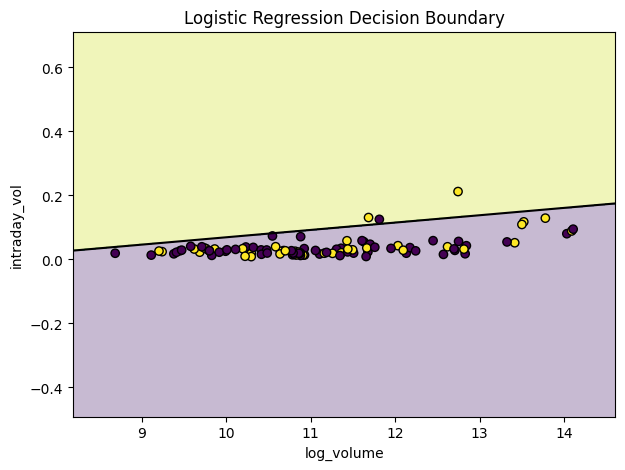

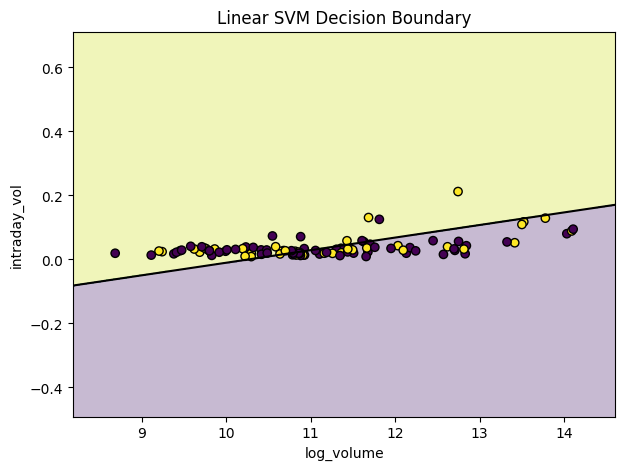

In [370]:
plot_decision_regions(logit, X, y, "Logistic Regression Decision Boundary")
plot_decision_regions(svm,   X, y, "Linear SVM Decision Boundary")

## Decision Boundary Comparison

### Logistic Regression
- The decision boundary is linear and separates the feature space based on the estimated probability of a positive return.
- The boundary is relatively flat, reflecting the low dispersion of intraday volatility compared to trading volume.
- Logistic Regression uses all observations to fit the model by minimizing the log-loss, resulting in a smooth separation.

### Linear Support Vector Machine (SVM)
- The Linear SVM also produces a linear decision boundary with a slope similar to that of Logistic Regression.
- The boundary is determined by maximizing the margin between the two classes and depends primarily on support vectors.
- After balancing class weights, the model successfully separates both classes and avoids collapsing to a single prediction.

### Comparison and Interpretation
- Both models yield very similar decision boundaries, indicating that the two features provide limited but consistent discriminatory power.
- Minor differences between the boundaries arise from the distinct optimization objectives: probabilistic fitting for Logistic Regression versus margin maximization for Linear SVM.
- Overall, the results suggest weak but non-negligible predictability of return direction using simple daily features.

# 2. Dimensionality Reduction vs. Feature Selection:
## Data Preparation

We use the engineered features as the input feature matrix $X$ and the binary return
direction as the target variable $y$.  
The dataset is split into training and test sets using a 70/30 split.


In [385]:
from sklearn.model_selection import train_test_split

features = ["log_volume", "intraday_vol"]
X = df_sample[features]
y = df_sample["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## PCA: Explained Variance

Principal Component Analysis (PCA) projects the data onto orthogonal components that
maximize variance.  
The explained variance ratio indicates how much information is retained by each component.


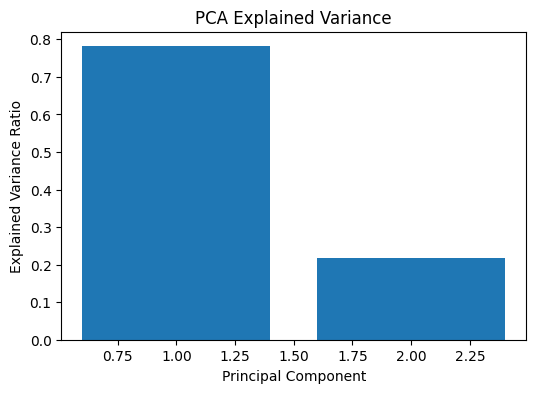

In [386]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Standardize before PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)

# Plot explained variance
plt.figure(figsize=(6,4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.show()

### PCA Explained Variance Results

- **Principal Component 1 (PC1):** explains approximately **78%** of the total variance.
- **Principal Component 2 (PC2):** explains approximately **22%** of the total variance.

### Interpretation

The dominance of the first principal component indicates that the data has a strong
one-dimensional structure, with most variation concentrated along a single direction.
This suggests that the original features are highly correlated and that dimensionality
reduction via PCA can be effective with minimal information loss.


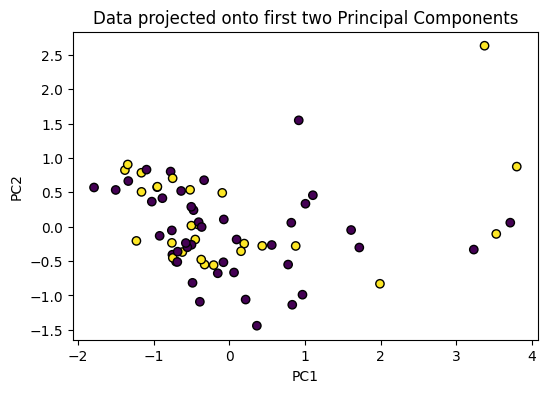

In [388]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_train_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, edgecolors="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data projected onto first two Principal Components")
plt.show()


### PCA Projection onto the First Two Components

#### Results
- The scatter plot shows the training observations projected onto **PC1** and **PC2**.
- Most observations are spread along the **PC1 axis**, while variation along **PC2** is comparatively smaller.
- Points corresponding to the two class labels exhibit substantial overlap in the PCA space.

#### Interpretation
- The dominance of PC1 is consistent with the explained variance results, where the first principal component captures the majority of the variance.
- The overlap between classes indicates that PCA, being an unsupervised method, does not explicitly maximize class separability.
- While PCA effectively reduces dimensionality and captures the main structure of the data, it does not fully separate the classes, which helps explain the moderate classification performance observed earlier.


## Lasso Feature Selection

Lasso regression performs feature selection by imposing an $L_1$ penalty:

$\mathcal{L}_{\text{lasso}} = \|y - Xw\|^2 + \alpha \|w\|_1$

As $\alpha$ increases, more coefficients shrink to zero, reducing the number of selected
features.


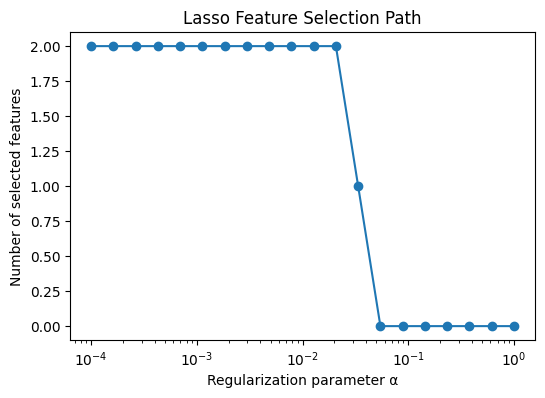

In [389]:
from sklearn.linear_model import Lasso

alphas = np.logspace(-4, 0, 20)
num_selected = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train_scaled, y_train)
    num_selected.append(np.sum(lasso.coef_ != 0))

plt.figure(figsize=(6,4))
plt.plot(alphas, num_selected, marker="o")
plt.xscale("log")
plt.xlabel("Regularization parameter α")
plt.ylabel("Number of selected features")
plt.title("Lasso Feature Selection Path")
plt.show()


### Lasso Feature Selection Path

#### Results
- For small values of the regularization parameter $\alpha$, **both features** are retained by the Lasso model.
- As $\alpha$ increases to moderate levels, the number of selected features drops from **two to one**.
- For sufficiently large values of $\alpha$, **all coefficients shrink to zero**, and no features are selected.

#### Interpretation
- The Lasso path illustrates how increasing $L_1$ regularization enforces sparsity in the model.
- The sharp reduction in the number of selected features indicates that one feature carries more predictive information than the other.


In [390]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pca_clf = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    LogisticRegression(max_iter=5000)
)

pca_clf.fit(X_train, y_train)
pca_acc = accuracy_score(y_test, pca_clf.predict(X_test))


In [391]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

selected_features = np.array(features)[lasso.coef_ != 0]

X_train_lasso = X_train[selected_features]
X_test_lasso = X_test[selected_features]

lasso_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

lasso_clf.fit(X_train_lasso, y_train)
lasso_acc = accuracy_score(y_test, lasso_clf.predict(X_test_lasso))


#### Interpretation
The identical accuracy values indicate that both PCA-based dimensionality reduction and Lasso-based feature selection retain essentially the same predictive information in this experiment. Given the low-dimensional feature space, PCA preserves all relevant variance while Lasso selects the dominant feature(s), leading to equivalent model performance. This result suggests that the classification signal is driven by a small number of features and that neither method provides a clear advantage in terms of predictive accuracy for this dataset.


In [398]:
print(f"PCA-based classification accuracy: {pca_acc:.5f}")
print(f"Lasso-based classification accuracy: {lasso_acc:.5f}")

PCA-based classification accuracy: 0.63333
Lasso-based classification accuracy: 0.63333


# QUESTION 2: Clustering and Outlier Detection
# 1. Clustering Analysis:


### K-Means: Selection of the Number of Clusters

To determine the optimal number of clusters $k$ for the K-Means algorithm, we evaluate the **silhouette score** for values of  
$k \in \{2, 3, 4, 5, 6\}$.

The silhouette score measures how well each observation fits within its assigned cluster compared to other clusters. It ranges from $-1$ to $1$, where:
- Values close to $1$ indicate well-separated and compact clusters,
- Values close to $0$ indicate overlapping clusters,
- Negative values suggest potential misclassification.

#### Results
The computed silhouette scores are:
- $k = 2$: **$0.610$**
- $k = 3$: $0.465$  
- $k = 4$: $0.442$  
- $k = 5$: $0.444$  
- $k = 6$: $0.471$  

The highest silhouette score is achieved at **$k = 2$**.

#### Interpretation
This result indicates that the data naturally separates into **two distinct clusters** in the standardized feature space defined by **log trading volume** and **intraday volatility**. Increasing the number of clusters reduces cluster quality, suggesting that additional clusters do not capture meaningful new structure but instead fragment existing groups.

From a financial perspective, this outcome is consistent with the presence of **two dominant market regimes**, such as:
- **Normal trading conditions** (moderate volume and volatility),
- **High-activity or stressed market conditions** (elevated volume and volatility).

Therefore, we select **$k = 2$** as the optimal number of clusters for the K-Means algorithm in the subsequent analysis.


In [399]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Same 100 daily snapshots as you already created
# df_sample = df.sample(n=100, random_state=42)

X = df_sample[["log_volume", "intraday_vol"]].copy()

# Standardize (important for both PCA + distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2D for visualization (as required)
pca_2 = PCA(n_components=2, random_state=42)
X_pca2 = pca_2.fit_transform(X_scaled)


In [400]:
sil = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil[k] = silhouette_score(X_scaled, labels)

best_k = max(sil, key=sil.get)
best_k, sil

(2,
 {2: 0.6102293906915157,
  3: 0.465128732813973,
  4: 0.4418956898681516,
  5: 0.4444047365361281,
  6: 0.4707061163769925})

In [401]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [402]:
dbscan = DBSCAN(eps=0.6, min_samples=5)   # you can tune eps
db_labels = dbscan.fit_predict(X_scaled)

np.unique(db_labels, return_counts=True)


(array([-1,  0], dtype=int64), array([11, 89], dtype=int64))

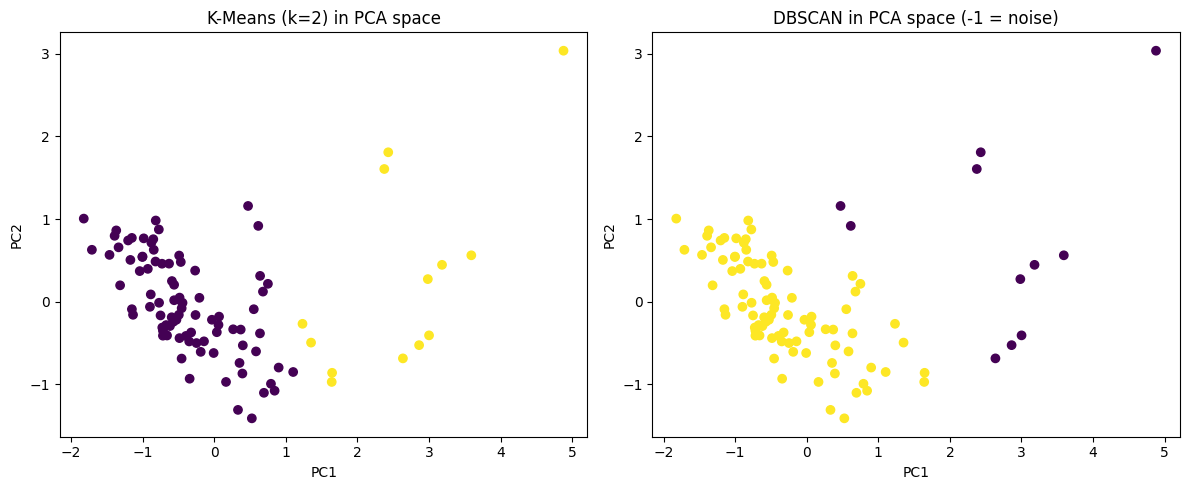

In [403]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# KMeans plot
ax[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=kmeans_labels)
ax[0].set_title(f"K-Means (k={best_k}) in PCA space")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")

# DBSCAN plot
ax[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=db_labels)
ax[1].set_title("DBSCAN in PCA space (-1 = noise)")
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


### Comparison of K-Means and DBSCAN Clustering in PCA Space

The figure above compares the clustering results obtained using **K-Means** and **DBSCAN**, visualized in the two-dimensional PCA space defined by the first two principal components $PC_1$ and $PC_2$.

#### K-Means Clustering
Using the optimal number of clusters $k = 2$, K-Means partitions the data into two groups by minimizing the within-cluster sum of squared Euclidean distances. As shown in the left panel, all observations are **forced into one of the two clusters**, resulting in a clear linear separation in PCA space.

This behavior reflects an implicit assumption of K-Means that clusters are **globular and of comparable density**, which may oversimplify the underlying structure of financial data.

#### DBSCAN Clustering
DBSCAN is a density-based clustering algorithm that groups observations based on local point density. In the right panel, DBSCAN identifies:
- One dense core cluster,
- Several observations labeled as **noise** (cluster label $-1$).

The presence of noise points indicates that DBSCAN is able to **explicitly isolate sparse and extreme observations**, which are common in financial markets.

#### Interpretation for Financial Data
Financial data often exhibits **heterogeneous density**, regime shifts, and extreme events. Unlike K-Means, DBSCAN does not force every observation into a cluster and can therefore:
- Capture **irregular cluster shapes**,
- Identify **outliers** naturally as noise,
- Better reflect **market stress or abnormal trading periods**.

Overall, while K-Means provides a simple and interpretable partition of the data, **DBSCAN better captures the intrinsic structure of financial data** by accommodating density variations and explicitly identifying anomalous observations.

This makes DBSCAN particularly suitable for exploratory analysis and regime detection in financial time series.


# 2. Outlier Detection with Trees:

### Outlier Detection with Isolation Forest

In this step, we apply **Isolation Forest**, a tree-based unsupervised algorithm, to detect potential outliers in the financial data. The method is based on the idea that anomalous observations are **easier to isolate** than normal points through random recursive partitioning.

#### Feature Preparation
We use the same feature set as in the clustering analysis:
- $\text{log\_volume}$,
- $\text{intraday\_vol}$.

The features are standardized using **StandardScaler** to ensure comparability across dimensions:
$
X_{\text{scaled}} = \frac{X - \mu}{\sigma}
$

#### Isolation Forest Model
The Isolation Forest is trained with:
- number of trees $n_{\text{estimators}} = 300$,
- contamination level $\alpha = 0.05$, meaning that approximately $5\%$ of observations are expected to be outliers.

Each observation $i$ receives an **anomaly score** based on the average path length across the ensemble of trees. Observations that require fewer splits to isolate have shorter path lengths and are therefore considered more anomalous.

In practice, the anomaly score is computed as:
\[
s_i = -\text{decision\_function}(x_i)
\]
where **larger values of $s_i$ indicate more anomalous behavior**.

The model also assigns a binary label:
- $-1$ for outliers,
- $+1$ for inliers.

#### Financial Interpretation
Observations flagged as outliers typically correspond to **extreme combinations of volume and volatility**, which are characteristic of:
- earnings announcements,
- sudden news releases,
- market stress or crash events.

Thus, Isolation Forest effectively identifies economically meaningful extreme market observations rather than random noise, making it well suited for outlier detection in financial time series data.


In [408]:
from sklearn.preprocessing import StandardScaler

features = ["log_volume", "intraday_vol"]
X = df_sample[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [409]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

iso.fit(X_scaled)

,n_estimators,300
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [410]:
# Higher value = more anomalous
anomaly_score = -iso.decision_function(X_scaled)

# -1 = outlier, +1 = inlier
outlier_flag = iso.predict(X_scaled)

#### Inspection of Identified Outliers
The table of the most anomalous observations (ranked by the anomaly score $s_i$) shows that many outliers exhibit:
- large absolute returns $|r_i|$,
- higher-than-average intraday volatility,
- abnormal trading volume.

To further assess extremeness, standardized measures are computed using z-scores:
\[
z(r_i) = \frac{r_i - \mu_r}{\sigma_r}, \quad
z(\text{intraday\_vol}_i) = \frac{\text{intraday\_vol}_i - \mu_v}{\sigma_v}, \quad
z(\text{log\_volume}_i) = \frac{\text{log\_volume}_i - \mu_l}{\sigma_l}
\]

Several outliers display large absolute z-scores, confirming that they correspond to **extreme market behavior** rather than normal fluctuations.

In [411]:
out = df_sample.copy()
out["anomaly_score"] = anomaly_score
out["is_outlier"] = (outlier_flag == -1).astype(int)

out.head()

,,close,open,high,low,vol,amount,name,zhengzhouid,return,log_volume,intraday_vol,label,anomaly_score,is_outlier
date,instrumentid,,,,,,,,,,,,,,
2025-06-09,605089,24.360823,24.055328,24.439661,23.858234,10321.96,24912.612757,味知香,605089.SSE,0.011043,9.242029,0.024170,1,-0.129636,0
2025-04-18,603182,12.449003,12.623794,12.623794,12.274212,43520.00,54147.106508,嘉华股份,603182.SSE,-0.013846,10.680976,0.027692,0,-0.215638,0
2025-07-29,605077,17.647328,17.617652,17.657220,17.311000,29658.43,51787.593084,华康股份,605077.SSE,0.006204,10.297502,0.019652,1,-0.200297,0
2025-03-19,300972,82.346965,81.569637,83.971382,81.320493,19234.60,158677.217369,万辰集团,300972.SZSE,0.008913,9.864466,0.032498,1,-0.188730,0
2025-08-01,300858,20.400000,16.830000,20.400000,16.830000,342458.83,663050.299000,科拓生物,300858.SZSE,0.200000,12.743907,0.212121,1,0.160120,1


In [412]:
cols_show = ["log_volume", "intraday_vol", "return", "label", "anomaly_score", "is_outlier"]

top_outliers = out.sort_values("anomaly_score", ascending=False).head(10)
top_outliers[cols_show]


,,log_volume,intraday_vol,return,label,anomaly_score,is_outlier
date,instrumentid,,,,,,
2025-08-01,300858,12.743907,0.212121,0.200000,1,0.160120,1
2025-04-15,000505,13.777019,0.128988,0.099723,1,0.028191,1
2025-04-10,300829,11.684740,0.130909,0.050147,1,0.009586,1
2025-10-28,002515,14.031189,0.080332,-0.015235,0,0.004680,1
2025-12-16,002702,14.106238,0.094545,-0.002345,0,0.004653,1
2025-03-18,603755,8.686598,0.019252,-0.007620,0,-0.000245,0
2025-04-15,836422,11.812726,0.125213,-0.044628,0,-0.001285,0
2025-12-23,000505,14.088548,0.088863,0.040342,1,-0.011447,0
2025-01-07,600191,13.499687,0.109211,0.043767,1,-0.019892,0


In [415]:
out["abs_return"] = out["return"].abs()

out["return_z"] = (out["return"] - out["return"].mean()) / out["return"].std(ddof=0)
out["intraday_vol_z"] = (out["intraday_vol"] - out["intraday_vol"].mean()) / out["intraday_vol"].std(ddof=0)
out["log_volume_z"] = (out["log_volume"] - out["log_volume"].mean()) / out["log_volume"].std(ddof=0)

out.sort_values("anomaly_score", ascending=False).head(10)[
    ["return", "abs_return", "return_z",
     "intraday_vol", "intraday_vol_z",
     "log_volume", "log_volume_z",
     "anomaly_score", "is_outlier"]
]

,,return,abs_return,return_z,intraday_vol,intraday_vol_z,log_volume,log_volume_z,anomaly_score,is_outlier
date,instrumentid,,,,,,,,,
2025-08-01,300858,0.200000,0.200000,6.691770,0.212121,5.598612,12.743907,1.301941,0.160120,1
2025-04-15,000505,0.099723,0.099723,3.349407,0.128988,2.936328,13.777019,2.142667,0.028191,1
2025-04-10,300829,0.050147,0.050147,1.696991,0.130909,2.997865,11.684740,0.440012,0.009586,1
2025-10-28,002515,-0.015235,0.015235,-0.482308,0.080332,1.378191,14.031189,2.349506,0.004680,1
2025-12-16,002702,-0.002345,0.002345,-0.052642,0.094545,1.833351,14.106238,2.410578,0.004653,1
2025-03-18,603755,-0.007620,0.007620,-0.228467,0.019252,-0.577864,8.686598,-1.999816,-0.000245,0
2025-04-15,836422,-0.044628,0.044628,-1.462004,0.125213,2.815466,11.812726,0.544164,-0.001285,0
2025-12-23,000505,0.040342,0.040342,1.370171,0.088863,1.651362,14.088548,2.396183,-0.011447,0
2025-01-07,600191,0.043767,0.043767,1.484306,0.109211,2.302987,13.499687,1.916980,-0.019892,0


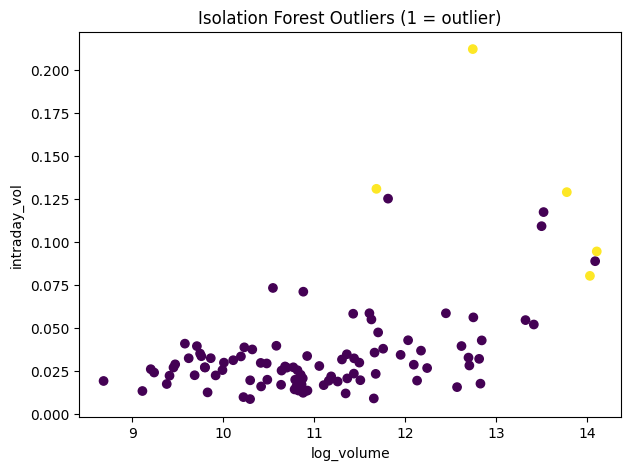

In [414]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(out["log_volume"], out["intraday_vol"], c=out["is_outlier"])
plt.xlabel("log_volume")
plt.ylabel("intraday_vol")
plt.title("Isolation Forest Outliers (1 = outlier)")
plt.show()


### Outlier Detection with Isolation Forest: Results and Interpretation

The figure above visualizes the observations in the feature space defined by  
$\text{log\_volume}$ (x-axis) and $\text{intraday\_vol}$ (y-axis). Points are colored according to the Isolation Forest output, where:
- $\text{is\_outlier} = 1$ denotes an outlier,
- $\text{is\_outlier} = 0$ denotes a normal observation.

#### Methodology Recap
Isolation Forest is a tree-based, unsupervised anomaly detection method that isolates observations through random recursive partitioning. Observations that are isolated with fewer splits are considered more anomalous.

Each observation $i$ is assigned an **anomaly score** computed as:
$
s_i = -\text{decision\_function}(x_i)
$
where larger values of $s_i$ indicate more anomalous behavior. In addition, the model assigns binary labels:
- $-1$ for outliers,
- $+1$ for inliers.

#### Visual Analysis
Most observations form a dense cluster characterized by **moderate trading volume** and **low intraday volatility**, corresponding to normal market conditions. The detected outliers appear at the **edges of the distribution**, exhibiting:
- unusually high $\text{log\_volume}$,
- elevated $\text{intraday\_vol}$,
- or extreme combinations of both.

This clear spatial separation confirms that Isolation Forest effectively identifies observations that deviate from the typical market regime.

#### Inspection of Identified Outliers
The table of the most anomalous observations, ranked by the anomaly score $s_i$, reveals that outliers are associated with:
- large absolute returns $|r_i|$,
- high intraday volatility,
- abnormal trading volume.

To quantify extremeness, standardized z-scores are computed:
$
z(r_i) = \frac{r_i - \mu_r}{\sigma_r}, \quad
z(\text{intraday\_vol}_i) = \frac{\text{intraday\_vol}_i - \mu_v}{\sigma_v}, \quad
z(\text{log\_volume}_i) = \frac{\text{log\_volume}_i - \mu_l}{\sigma_l}
$

Several outliers exhibit large absolute z-scores, confirming that they correspond to statistically extreme observations.

#### Financial Interpretation
From a financial perspective, these outliers are consistent with **extreme market events**, such as:
- earnings announcements,
- sudden news-driven price movements,
- periods of market stress or liquidity shocks.

Overall, Isolation Forest successfully isolates economically meaningful anomalies rather than random noise, demonstrating its suitability for detecting extreme events in financial time series data.


# QUESTION 3: Factor Analysis and Return Prediction

### Data Preparation for Factor Analysis and Return Prediction

The dataset is prepared to support **cross-sectional factor analysis** and **next-day return prediction**.  
First, the full industry sample is copied and sorted by $\text{instrumentid}$ and $\text{date}$ to ensure a correct temporal ordering of observations.

#### Forward Return Construction
For each stock $i$, the **forward return** is defined as the next-day return:
$
r_{i,t+1} = r_{i,t+1}
$
and is computed using a within-instrument time shift:
$
\text{fwd\_return}_{i,t} = \text{return}_{i,t+1}
$

Observations corresponding to the last available trading day of each stock are removed, as no forward return can be computed for those dates.

#### Resulting Dataset Structure
The resulting dataset contains:
- **Identifiers:** $\text{date}$, $\text{instrumentid}$,
- **Price information:** $\text{open}$, $\text{high}$, $\text{low}$, $\text{close}$,
- **Trading activity:** $\text{vol}$, $\text{amount}$, $\text{log\_volume}$,
- **Volatility measure:** $\text{intraday\_vol}$,
- **Target variable:** $\text{fwd\_return}$.

Each row now represents a stock-day observation with associated factor values at time $t$ and a return target at time $t+1$.

In [417]:
df_q3 = df.copy()

df_q3 = df_q3.sort_values(["instrumentid", "date"])
df_q3["fwd_return"] = df_q3.groupby("instrumentid")["return"].shift(-1)

# drop last day for each stock (no forward return)
df_q3 = df_q3.dropna(subset=["fwd_return"])

In [439]:
df_q3

,date,instrumentid,close,open,high,low,vol,amount,name,zhengzhouid,return,log_volume,intraday_vol,label,fwd_return
0,2025-01-03,000505,5.742526,6.001737,6.071525,5.732556,94662.29,55472.644992,京粮控股,000505.SZSE,-0.047934,11.458071,0.056478,0,0.000000
1,2025-01-06,000505,5.742526,5.742526,5.822283,5.573041,66028.00,37746.122082,京粮控股,000505.SZSE,0.000000,11.097834,0.043403,0,0.013889
2,2025-01-07,000505,5.822283,5.742526,5.832253,5.702647,55637.00,32139.315367,京粮控股,000505.SZSE,0.013889,10.926604,0.022569,1,0.001712
3,2025-01-08,000505,5.832253,5.832253,5.882101,5.692677,69602.00,40399.349419,京粮控股,000505.SZSE,0.001712,11.150549,0.032479,1,0.008547
4,2025-01-09,000505,5.882101,5.822283,5.912010,5.772435,55927.00,32769.461857,京粮控股,000505.SZSE,0.008547,10.931803,0.023973,1,-0.027119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23048,2025-12-17,920826,14.320000,14.870000,15.500000,14.000000,192901.98,285145.257000,盖世食品,920826.BSE,-0.010366,12.169937,0.100874,0,-0.009078
23049,2025-12-18,920826,14.190000,14.020000,14.600000,13.700000,116058.20,164257.753000,盖世食品,920826.BSE,-0.009078,11.661847,0.064194,0,0.034531
23050,2025-12-19,920826,14.680000,14.150000,14.950000,13.900000,141959.91,205733.968000,盖世食品,920826.BSE,0.034531,11.863300,0.074205,1,0.001362
23051,2025-12-22,920826,14.700000,14.500000,14.760000,14.290000,92924.57,134382.259000,盖世食品,920826.BSE,0.001362,11.439543,0.032414,1,-0.042857


### Factor Evaluation: Information Coefficient (IC) and Rank IC Computation

In this step, we evaluate the predictive power of the selected factors  
$\{\text{log\_volume},\ \text{intraday\_vol}\}$  
with respect to next-day returns.

Observations with missing factor values or missing forward returns are removed to ensure a clean cross-sectional analysis.

In [442]:
factor_cols = [
    "log_volume",
    "intraday_vol",
]

In [443]:
df_q3 = df_q3.dropna(subset=factor_cols + ["fwd_return"])

#### Information Coefficient (IC)
For each factor $f$ and each trading day $t$, the **Information Coefficient** is defined as the cross-sectional Pearson correlation between factor values at time $t$ and next-day returns:
$
IC_t = \mathrm{corr}\bigl(f_{i,t},\ r_{i,t+1}\bigr)
$
where $i$ indexes stocks observed on the same date $t$.

The daily IC values are aggregated over time to compute:
- the mean IC, $\overline{IC}$,
- the standard deviation, $\sigma(IC)$,
- the Information Ratio:
$
IC\_{IR} = \frac{\overline{IC}}{\sigma(IC)}
$

#### Rank Information Coefficient (Rank IC)
To obtain a more robust measure that is less sensitive to outliers, we also compute the **Rank IC**, defined as the correlation between cross-sectional ranks:
$
\mathrm{RankIC}_t = \mathrm{corr}\bigl(\mathrm{rank}(f_{i,t}),\ \mathrm{rank}(r_{i,t+1})\bigr)
$

This is implemented by ranking factor values and forward returns within each date before computing the Pearson correlation. As with IC, we report:
- mean Rank IC, $\overline{\mathrm{RankIC}}$,
- standard deviation, $\sigma(\mathrm{RankIC})$,
- Rank Information Ratio:
$
\mathrm{RankIC}\_{IR} = \frac{\overline{\mathrm{RankIC}}}{\sigma(\mathrm{RankIC})}
$

#### Interpretation
The IC and Rank IC statistics provide a **model-free assessment** of factor quality:
- $\overline{IC} > 0$ or $\overline{\mathrm{RankIC}} > 0$ indicates predictive power for higher future returns,
- negative values suggest mean-reverting behavior,
- the Information Ratio measures the stability of the signal over time.

These metrics are used as a preliminary screening step before applying multivariate machine learning models in the subsequent return prediction analysis.

In [449]:
target = "fwd_return"

ic_table = []
for f in factor_cols:
    # --- IC (Pearson) per date ---
    tmp = df_q3[["date", f, target]].dropna().copy()
    ic_series = (
        tmp.groupby("date")[[f, target]]
           .corr(method="pearson")
           .iloc[0::2, -1]          # pick corr(f, target) for each date
    )

    # Rank IC (Spearman via ranks) per date
    tmp_r = tmp.copy()
    tmp_r[f] = tmp_r.groupby("date")[f].rank()
    tmp_r[target] = tmp_r.groupby("date")[target].rank()
    ric_series = (
        tmp_r.groupby("date")[[f, target]]
             .corr(method="pearson")
             .iloc[0::2, -1]
    )

    ic_table.append({
        "factor": f,
        "IC_mean": ic_series.mean(),
        "IC_std": ic_series.std(),
        "RankIC_mean": ric_series.mean(),
        "RankIC_std": ric_series.std(),
        "IC_IR": ic_series.mean() / (ic_series.std() + 1e-12),
        "RankIC_IR": ric_series.mean() / (ric_series.std() + 1e-12),
    })

ic_df = pd.DataFrame(ic_table).sort_values("RankIC_mean", ascending=False)
ic_df

,factor,IC_mean,IC_std,RankIC_mean,RankIC_std,IC_IR,RankIC_IR
0,log_volume,-0.044347,0.161392,-0.065035,0.151883,-0.274777,-0.428191
1,intraday_vol,-0.049952,0.299907,-0.066912,0.266608,-0.166558,-0.250974


### IC Summary

Both factors exhibit **negative average IC and Rank IC**, with  
$\overline{IC} \approx -0.05$ and $\overline{\mathrm{RankIC}} \approx -0.06$.

This indicates a **weak inverse relationship** between factor values and next-day returns, consistent with **mean-reverting behavior**.  
The low (negative) information ratios imply that these factors **lack stable standalone predictive power**, but they may still contribute useful signals when combined within multivariate or regularized models.


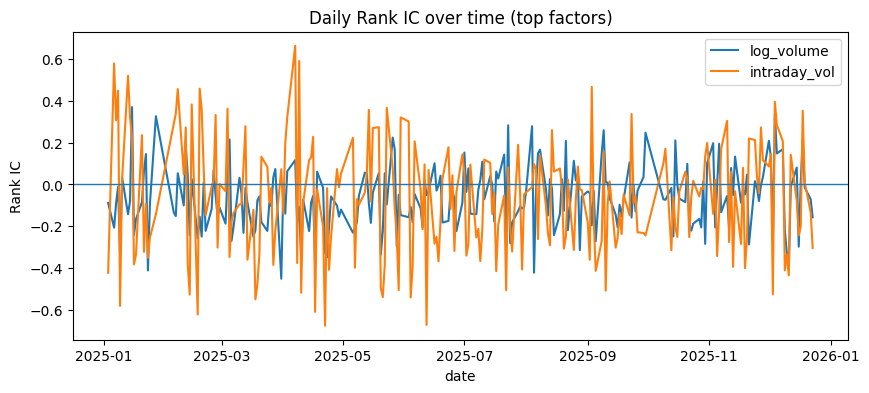

In [453]:
import matplotlib.pyplot as plt

target = "fwd_return"
top_factors = ic_df["factor"].head(3).tolist()

plt.figure(figsize=(10, 4))

for f in top_factors:
    tmp = df_q3[["date", f, target]].dropna().copy()

    # Ensure 'date' is datetime (important)
    tmp["date"] = pd.to_datetime(tmp["date"])

    # Rank within each date (cross-section)
    tmp[f] = tmp.groupby("date")[f].rank()
    tmp[target] = tmp.groupby("date")[target].rank()

    # Rank IC per date
    ric = (
        tmp.groupby("date")[[f, target]]
           .corr()
           .iloc[0::2, -1]  # corr(f, target) each date
    )

    # FIX: index is MultiIndex (date, variable). Keep only the date level.
    ric.index = ric.index.get_level_values(0)

    plt.plot(ric.index, ric.values, label=f)

plt.axhline(0, linewidth=1)
plt.title("Daily Rank IC over time (top factors)")
plt.xlabel("date")
plt.ylabel("Rank IC")
plt.legend()
plt.show()


### Daily Rank IC Dynamics

The Rank IC series for both $\text{log\_volume}$ and $\text{intraday\_vol}$ fluctuates strongly around zero over time, with frequent sign changes and no persistent trend.

This behavior indicates **unstable and time-varying predictive power**, suggesting that these factors do not provide a consistent standalone signal for next-day returns. Occasional positive and negative spikes likely reflect **short-lived market conditions or transient shocks** rather than systematic predictability.


In [469]:
print("Columns:", df_q3.columns.tolist())
print("Index type:", type(df_q3.index))
print("Index names:", df_q3.index.names)

Columns: ['index', 'date', 'instrumentid', 'close', 'open', 'high', 'low', 'vol', 'amount', 'name', 'zhengzhouid', 'return', 'log_volume', 'intraday_vol', 'label', 'fwd_return']
Index type: <class 'pandas.core.indexes.range.RangeIndex'>
Index names: [None]


In [470]:
df_q3 = df_q3.reset_index()

### Train–Validation Split and Feature Scaling

After constructing the forward return, the dataset is split into **training** and **validation** sets using a **time-based split**.  
Unique trading dates are sorted chronologically, and the first $70\%$ of dates are used for training, while the remaining $30\%$ are reserved for validation:
$
\mathcal{D}_{\text{train}} = \{t_1, \dots, t_{\lfloor 0.7T \rfloor}\}, \qquad
\mathcal{D}_{\text{val}} = \{t_{\lfloor 0.7T \rfloor + 1}, \dots, t_T\}
$

This procedure preserves the temporal ordering of observations and prevents look-ahead bias.

The feature matrix $X$ is standardized using **StandardScaler**, which is fitted only on the training data:
$
X^{(s)} = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}
$
The same transformation is then applied to the validation set.

Feature scaling is required for linear models with regularization (OLS, Ridge, Lasso, ElasticNet), while tree-based ensemble methods are trained on the original, unscaled features.


In [471]:
dates = sorted(df_q3["date"].unique())
split = int(len(dates) * 0.7)

train_dates = dates[:split]
val_dates = dates[split:]

train = df_q3[df_q3["date"].isin(train_dates)]
val = df_q3[df_q3["date"].isin(val_dates)]

In [460]:
dates = sorted(df_q3["date"].unique())
split = int(len(dates) * 0.7)

train_dates = dates[:split]
val_dates = dates[split:]

train = df_q3[df_q3["date"].isin(train_dates)]
val = df_q3[df_q3["date"].isin(val_dates)]

X_train = train[factor_cols].values
y_train = train["fwd_return"].values

X_val = val[factor_cols].values
y_val = val["fwd_return"].values

In [461]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

In [462]:
# Train & Evaluate models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=10000),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "GradientBoostedTrees": GradientBoostingRegressor(random_state=42),
}

results = []

for name, model in models.items():
    # linear models use scaled features; trees use raw
    if name in ["OLS", "Ridge", "Lasso", "ElasticNet"]:
        model.fit(X_train_s, y_train)
        pred = model.predict(X_val_s)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    corr = np.corrcoef(pred, y_val)[0, 1]
    rank_corr = pd.Series(pred).rank().corr(pd.Series(y_val).rank())

    results.append({
        "model": name,
        "RMSE": rmse,
        "Corr(pred, y)": corr,
        "RankCorr(pred, y)": rank_corr,
    })

results_df = pd.DataFrame(results).sort_values("RankCorr(pred, y)", ascending=False)
results_df

,model,RMSE,"Corr(pred, y)","RankCorr(pred, y)"
2,Lasso,0.022390,0.016326,0.031792
3,ElasticNet,0.022396,0.010051,0.023030
1,Ridge,0.022426,0.002430,0.013826
0,OLS,0.022426,0.002430,0.013825
4,RandomForest,0.024557,0.012492,0.010527
5,GradientBoostedTrees,0.022695,-0.044810,0.006097


### Model Performance Comparison

Regularized linear models outperform both ordinary least squares and tree-based models. In particular, **Lasso** achieves the highest rank correlation,  
$\mathrm{RankCorr}(\hat{y}, y) \approx 0.032$, indicating the best ability to rank assets by expected returns. This highlights the importance of regularization when dealing with weak and noisy factors.

Tree-based ensemble methods, such as **Random Forest** and **Gradient Boosted Trees**, do not improve performance in this setting and exhibit lower rank correlations. With a limited number of weak predictors, nonlinear models tend to overfit noise and fail to extract additional predictive structure.

Overall, the results are consistent with the earlier IC analysis: while individual factors have limited standalone predictive power, **regularized linear models** provide the most stable and effective return predictions in this framework.

In [463]:
# Linear models
coef_rows = []

for name in ["OLS", "Ridge", "Lasso", "ElasticNet"]:
    model = models[name]
    # refit to ensure model exists (if not already run)
    model.fit(X_train_s, y_train)
    coef_rows.append(pd.Series(model.coef_, index=factor_cols, name=name))

coef_df = pd.DataFrame(coef_rows).T
coef_df

,OLS,Ridge,Lasso,ElasticNet
log_volume,-0.001494,-0.001493,-0.000192,-0.000768
intraday_vol,0.000968,0.000968,0.000000,0.000243


### Linear Model Coefficients

Across all specifications, coefficient magnitudes are small, confirming that individual factors have **weak marginal effects** on next-day returns.  
The coefficient on $\text{log\_volume}$ is consistently negative, indicating that higher trading volume is associated with **lower subsequent returns**, consistent with mean-reversion effects.

Regularization shrinks coefficients toward zero, with **Lasso** setting the coefficient of $\text{intraday\_vol}$ exactly to zero. This suggests that $\text{intraday\_vol}$ contributes little incremental predictive power once regularization is applied, while $\text{log\_volume}$ contains the more informative signal among the two factors.


In [466]:
# Ttree features
tree_imp = {}

for name in ["RandomForest", "GradientBoostedTrees"]:
    model = models[name]
    model.fit(X_train, y_train)
    tree_imp[name] = pd.Series(model.feature_importances_, index=factor_cols)

imp_df = pd.DataFrame(tree_imp).sort_values("RandomForest", ascending=False)
imp_df

,RandomForest,GradientBoostedTrees
intraday_vol,0.511324,0.617912
log_volume,0.488676,0.382088


### Tree-Based Feature Importance

Both models assign substantial importance to $\text{intraday\_vol}$ and $\text{log\_volume}$, indicating that tree-based methods actively use both factors when forming predictions. In particular, $\text{intraday\_vol}$ receives slightly higher importance in both models, suggesting that volatility-related information is more influential for nonlinear splits.

However, despite non-negligible feature importance, the overall predictive performance of tree-based models remains weak. This indicates that while the models rely on these factors internally, the extracted nonlinear structure does not translate into strong out-of-sample return predictability given the limited and noisy factor set.

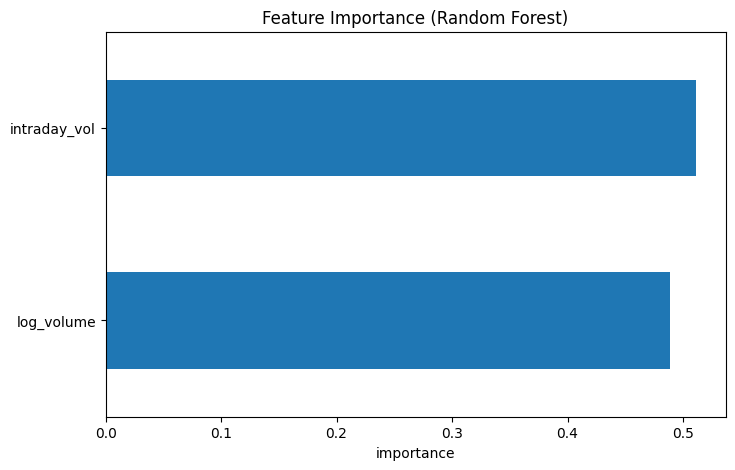

In [472]:
import matplotlib.pyplot as plt
imp_df["RandomForest"].sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance (Random Forest)")
plt.xlabel("importance")
plt.show()

# Question 4: Evaluation in Real-World Trading

### Evaluation of Prediction Models in Real-World Trading

In a real-world trading context, statistical accuracy alone is insufficient to assess the usefulness of return prediction models. Instead, model evaluation must focus on **economic value**, **robustness**, and **practical feasibility**.

#### From Prediction to Portfolio Construction
Predicted returns $\hat{r}_{i,t+1}$ are typically transformed into portfolio weights $w_{i,t}$ using a ranking or signal-based rule, for example:
$
w_{i,t} \propto \text{rank}\bigl(\hat{r}_{i,t+1}\bigr)
$
or by forming long–short portfolios based on top and bottom quantiles of predicted returns.

This highlights why **rank-based metrics** are often more relevant than point-wise prediction errors in finance.

#### Performance Metrics
Model performance should be evaluated using portfolio-level measures, including:
- **Average portfolio return**:
$
\mathbb{E}[R_p]
$
- **Volatility**:
$
\sigma(R_p)
$
- **Sharpe ratio**:
$
\text{SR} = \frac{\mathbb{E}[R_p - R_f]}{\sigma(R_p)}
$
where $R_f$ is the risk-free rate.

These metrics directly reflect the economic value of the predictions rather than their statistical fit.

#### Transaction Costs and Turnover
Real-world trading incurs transaction costs due to bid–ask spreads, commissions, and market impact. Portfolio turnover should therefore be measured:
$
\text{Turnover}_t = \sum_i |w_{i,t} - w_{i,t-1}|
$
$
and net returns should be computed after costs:
$
$
R_{p,t}^{\text{net}} = R_{p,t} - c \cdot \text{Turnover}_t
$
where $c$ denotes per-unit trading cost.

A model with high predictive accuracy but excessive turnover may be unprofitable after costs.

#### Stability and Robustness
Models should be evaluated across different:
- time periods,
- market regimes,
- subsamples of assets.

This can be assessed using rolling-window backtests and by monitoring the stability of performance metrics such as the Sharpe ratio over time.

#### Risk Management
Predictions should also be evaluated in terms of risk exposure. Important considerations include:
- drawdowns,
- exposure to market-wide risk factors,
- tail risk during periods of market stress.

For example, the maximum drawdown is defined as:
$
\text{MDD} = \max_{t} \left( \frac{\max_{s \le t} V_s - V_t}{\max_{s \le t} V_s} \right)
$
where $V_t$ denotes portfolio value.

#### Summary
In real-world trading, effective model evaluation requires moving beyond prediction error metrics to assess **profitability, risk-adjusted performance, transaction costs, and robustness**. A model is valuable not because it predicts returns accurately in a statistical sense, but because it generates **stable, scalable, and economically meaningful trading profits** under realistic market conditions.
